# Appendix B: Elliptic Regularity

**Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Appendix B, printed pp. 549-578; PDF pp. 564-593. Source pages were read with Poppler `pdftotext` for orientation only; the prose, examples, code, and artifacts below are original teaching material.

## Chapter Goal

This notebook explains why the weak analytic objects used to set up moduli spaces do not remain merely weak. Sobolev spaces provide a controlled completion, the Calderon-Zygmund inequality controls second derivatives through the Laplace operator, Laplace regularity upgrades weak solutions, and elliptic bootstrapping repeats those gains until a weak pseudoholomorphic curve is as smooth as the data allow.

## Computational Translation Guide

| Chapter language | Computational model in this notebook | What to inspect |
| --- | --- | --- |
| Weak derivative | Integration-by-parts identity and frequency-weighted derivatives | The derivative is tested against probes rather than pointwise formulas. |
| `W^{k,p}` Sobolev control | For `p=2`, Fourier coefficients weighted by powers of frequency | Higher `s` asks the coefficient tail to decay faster. |
| Calderon-Zygmund inequality | Bounded second-derivative Fourier multipliers | The Hessian multiplier has exact `L2` norm one in the flat periodic model. |
| Laplace regularity | Inverting the Laplacian divides nonzero modes by `|xi|^2` | The solution gains two derivatives relative to the forcing. |
| Bootstrapping | A finite exponent ladder for `du` and products with `dJ` | The exponents improve until Sobolev embedding supplies continuity. |
| Weak-to-smooth upgrade | Dependency graph from weak equation to smooth curve | Every analytic estimate feeds a specific regularity step. |


## Source Coverage And Library Routing

The appendix has four analytic layers. The notebook keeps them separate so the learner can see which estimate does which job. B.1 supplies the function spaces and embedding/trace tools, B.2 proves the second-derivative estimate for the Laplacian, B.3 turns that estimate into local regularity for weak Laplace equations, and B.4 applies the mechanism to the first-order Cauchy-Riemann type equation for curves with totally real boundary conditions.

The library choices are intentionally modest. This is not a mesh, projective, or 3D geometry chapter. Matplotlib gives durable frequency and multiplier diagrams, NetworkX makes the proof dependencies inspectable, Plotly is used only for the parameter-sensitive bootstrapping ladder, SymPy checks the exact multiplier identity, and NumPy/Pandas handle the finite models and ledgers.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import display


def find_book_root(start=None):
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "J-Holomorphic-Curves-and-Symplectic-Topology"]:
            if (candidate / "AGENTS.md").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("JHCST book root not found")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "appendix-b"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
HTML_DIR = ARTIFACT_ROOT / "html"
for folder in [FIG_DIR, CHECK_DIR, TABLE_DIR, HTML_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def write_csv(rows, path, fieldnames):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    return path


SOURCE_SPAN = {
    "printed_pages": "549-578",
    "pdf_pages": "564-593",
    "sections": "B.1-B.4",
}
BOOK_ROOT


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology')

In [2]:
source_coverage = [
    {
        "source_section": "B.1 Sobolev spaces",
        "printed_pages": "549-562",
        "coverage": "Weak derivatives, W^{k,p}, smooth approximation, Poincare, Sobolev embedding, trace, and manifold-valued map caveat.",
        "notebook_evidence": "Sobolev frequency-tail visual, invariant ledger, and source notes on embedding thresholds.",
        "artifact": "figures/sobolev-frequency-weights.png",
        "validation": "partial energy growth separates H^0/H^1 behavior from failed H^2 behavior in the model.",
    },
    {
        "source_section": "B.2 Calderon-Zygmund inequality",
        "printed_pages": "562-568",
        "coverage": "Fundamental solution, Weyl lemma context, singular-integral estimate, and control of second derivatives by the Laplacian.",
        "notebook_evidence": "Multiplier heatmaps and exact L2 Hessian identity for the flat model.",
        "artifact": "figures/calderon-zygmund-symbols.png",
        "validation": "symbolic and numeric Hessian multiplier norm checks.",
    },
    {
        "source_section": "B.3 Regularity for the Laplace operator",
        "printed_pages": "568-570",
        "coverage": "Interior regularity, cutoff localization, harmonic remainder, and divergence-form weak data.",
        "notebook_evidence": "Fourier inverse-Laplace smoothing visual and regularity JSON.",
        "artifact": "figures/elliptic-fourier-smoothing.png",
        "validation": "inverse-Laplace residual and two-derivative Sobolev norm gain.",
    },
    {
        "source_section": "B.4 Elliptic bootstrapping",
        "printed_pages": "571-578",
        "coverage": "Regularity and compactness for J-holomorphic curves, product estimates, exponent iteration, and weak-to-smooth upgrade.",
        "notebook_evidence": "Proof dependency map and bootstrapping exponent ladder.",
        "artifact": "figures/bootstrapping-exponent-ladder.png; html/bootstrapping-exponent-ladder.html",
        "validation": "finite exponent ladder reaches the r > 2 embedding threshold and final W^{1,p} recovery.",
    },
]

library_routing = [
    {
        "concept": "Sobolev spaces and embeddings",
        "library": "NumPy + Matplotlib",
        "why": "Frequency weights give a direct finite model of weak derivative control for p=2.",
        "fallback": "Static table of coefficient tail exponents.",
    },
    {
        "concept": "Calderon-Zygmund estimate",
        "library": "NumPy + Matplotlib + SymPy",
        "why": "The flat multiplier symbol is visible as a heatmap and its norm identity is exact.",
        "fallback": "Pure SymPy identity and numeric norm ledger.",
    },
    {
        "concept": "Laplace regularity",
        "library": "NumPy + Matplotlib",
        "why": "The inverse Laplacian is most transparent as high-frequency damping.",
        "fallback": "Coefficient table without plotting.",
    },
    {
        "concept": "Proof dependencies and weak-to-smooth upgrade",
        "library": "NetworkX + Matplotlib",
        "why": "The proof is a dependency chain; a directed acyclic graph exposes what each estimate unlocks.",
        "fallback": "Ordered ledger with edge list checks.",
    },
    {
        "concept": "Bootstrapping exponent ladder",
        "library": "Plotly + Matplotlib",
        "why": "The iteration depends on p and q; Plotly makes the threshold crossing inspectable, with a PNG fallback.",
        "fallback": "CSV ladder and static Matplotlib plot.",
    },
]

visual_storyboard = [
    {
        "order": 1,
        "concept": "Sobolev membership as tail decay",
        "representation": "Log-log coefficient and partial-energy plot",
        "artifact": "figures/sobolev-frequency-weights.png",
        "inspection_target": "Which weighted energies stabilize and which keep growing.",
        "check": "checks/sobolev-frequency-checks.json",
    },
    {
        "order": 2,
        "concept": "Calderon-Zygmund second-derivative control",
        "representation": "Fourier multiplier heatmaps",
        "artifact": "figures/calderon-zygmund-symbols.png",
        "inspection_target": "Second derivative multipliers are bounded away from the zero mode.",
        "check": "checks/calderon-zygmund-symbol-check.json",
    },
    {
        "order": 3,
        "concept": "Laplace regularity as two-derivative gain",
        "representation": "Preserved Fourier smoothing visual",
        "artifact": "figures/elliptic-fourier-smoothing.png",
        "inspection_target": "The solution tail drops by k^2 compared with the forcing tail.",
        "check": "checks/elliptic-regularity-checks.json",
    },
    {
        "order": 4,
        "concept": "Weak-to-smooth proof route",
        "representation": "Directed dependency graph",
        "artifact": "figures/proof-dependency-map.png",
        "inspection_target": "The path from weak equation to smooth curve has no circular dependency.",
        "check": "checks/proof-dependency-map.json",
    },
    {
        "order": 5,
        "concept": "Elliptic bootstrapping exponents",
        "representation": "Interactive HTML plus PNG fallback",
        "artifact": "html/bootstrapping-exponent-ladder.html",
        "inspection_target": "The r exponent crosses 2 after finitely many improvements of q.",
        "check": "checks/bootstrapping-exponent-ladder.json",
    },
]

invariant_rows = [
    {"item": "weak derivative", "computational_object": "test-function identity", "check": "source coverage includes weak solution and divergence-form rows"},
    {"item": "Sobolev norm", "computational_object": "frequency-weighted coefficient sum", "check": "H^s partial energy growth matches the decay threshold"},
    {"item": "Calderon-Zygmund inequality", "computational_object": "bounded Hessian multiplier", "check": "symbolic Hessian multiplier identity equals one"},
    {"item": "Laplace regularity", "computational_object": "inverse-Laplace coefficient damping", "check": "k^2 u_hat recovers f_hat"},
    {"item": "elliptic bootstrapping", "computational_object": "q/r exponent ladder", "check": "finite ladder reaches r > 2"},
    {"item": "weak-to-smooth upgrade", "computational_object": "DAG of proof dependencies", "check": "directed acyclic graph with weak-to-smooth terminal node"},
]

source_json = save_json({"source_span": SOURCE_SPAN, "sections": source_coverage, "passed": len(source_coverage) == 4}, UNIT, "checks", "source-coverage.json")
library_json = save_json({"routing": library_routing, "passed": len(library_routing) >= 5}, UNIT, "checks", "library-routing.json")
story_json = save_json({"source_span": SOURCE_SPAN, "library_routing": library_routing, "visuals": visual_storyboard, "passed": len(visual_storyboard) >= 5}, UNIT, "checks", "visual-storyboard.json")
ledger_csv = write_csv(invariant_rows, TABLE_DIR / "invariant-ledger.csv", ["item", "computational_object", "check"])
ledger_json = save_json({"row_count": len(invariant_rows), "items": [row["item"] for row in invariant_rows], "passed": len(invariant_rows) >= 6}, UNIT, "checks", "invariant-ledger.json")

print("Source coverage JSON:", rel(source_json))
print("Library routing JSON:", rel(library_json))
print("Visual storyboard JSON:", rel(story_json))
display(pd.DataFrame(source_coverage))
display(pd.DataFrame(library_routing))
display_artifact(ledger_csv)


Source coverage JSON: artifacts/appendix-b/checks/source-coverage.json
Library routing JSON: artifacts/appendix-b/checks/library-routing.json
Visual storyboard JSON: artifacts/appendix-b/checks/visual-storyboard.json


,source_section,printed_pages,coverage,notebook_evidence,artifact,validation
0,B.1 Sobolev spaces,549-562,"Weak derivatives, W^{k,p}, smooth approximatio...","Sobolev frequency-tail visual, invariant ledge...",figures/sobolev-frequency-weights.png,partial energy growth separates H^0/H^1 behavi...
1,B.2 Calderon-Zygmund inequality,562-568,"Fundamental solution, Weyl lemma context, sing...",Multiplier heatmaps and exact L2 Hessian ident...,figures/calderon-zygmund-symbols.png,symbolic and numeric Hessian multiplier norm c...
2,B.3 Regularity for the Laplace operator,568-570,"Interior regularity, cutoff localization, harm...",Fourier inverse-Laplace smoothing visual and r...,figures/elliptic-fourier-smoothing.png,inverse-Laplace residual and two-derivative So...
3,B.4 Elliptic bootstrapping,571-578,Regularity and compactness for J-holomorphic c...,Proof dependency map and bootstrapping exponen...,figures/bootstrapping-exponent-ladder.png; htm...,finite exponent ladder reaches the r > 2 embed...


,concept,library,why,fallback
0,Sobolev spaces and embeddings,NumPy + Matplotlib,Frequency weights give a direct finite model o...,Static table of coefficient tail exponents.
1,Calderon-Zygmund estimate,NumPy + Matplotlib + SymPy,The flat multiplier symbol is visible as a hea...,Pure SymPy identity and numeric norm ledger.
2,Laplace regularity,NumPy + Matplotlib,The inverse Laplacian is most transparent as h...,Coefficient table without plotting.
3,Proof dependencies and weak-to-smooth upgrade,NetworkX + Matplotlib,The proof is a dependency chain; a directed ac...,Ordered ledger with edge list checks.
4,Bootstrapping exponent ladder,Plotly + Matplotlib,The iteration depends on p and q; Plotly makes...,CSV ladder and static Matplotlib plot.


## B.1 Sobolev Spaces: Derivatives That Can Be Tested

A weak derivative is not a new pointwise formula. It is a promise that integration by parts works against every compactly supported test function. Sobolev spaces collect functions whose weak derivatives up to a chosen order live in an `L^p` space. This lets analysis happen in Banach spaces while still remembering derivative information.

For a compact periodic model with `p=2`, the Sobolev norm has a clean frequency interpretation. A derivative multiplies the `k`-th Fourier coefficient by roughly `k`, so each extra derivative asks for faster decay in the coefficient tail. The visual below uses the model `|u_k| = k^{-alpha}`. The threshold `s < alpha - 1/2` predicts which `H^s` energies remain stable as more modes are included.


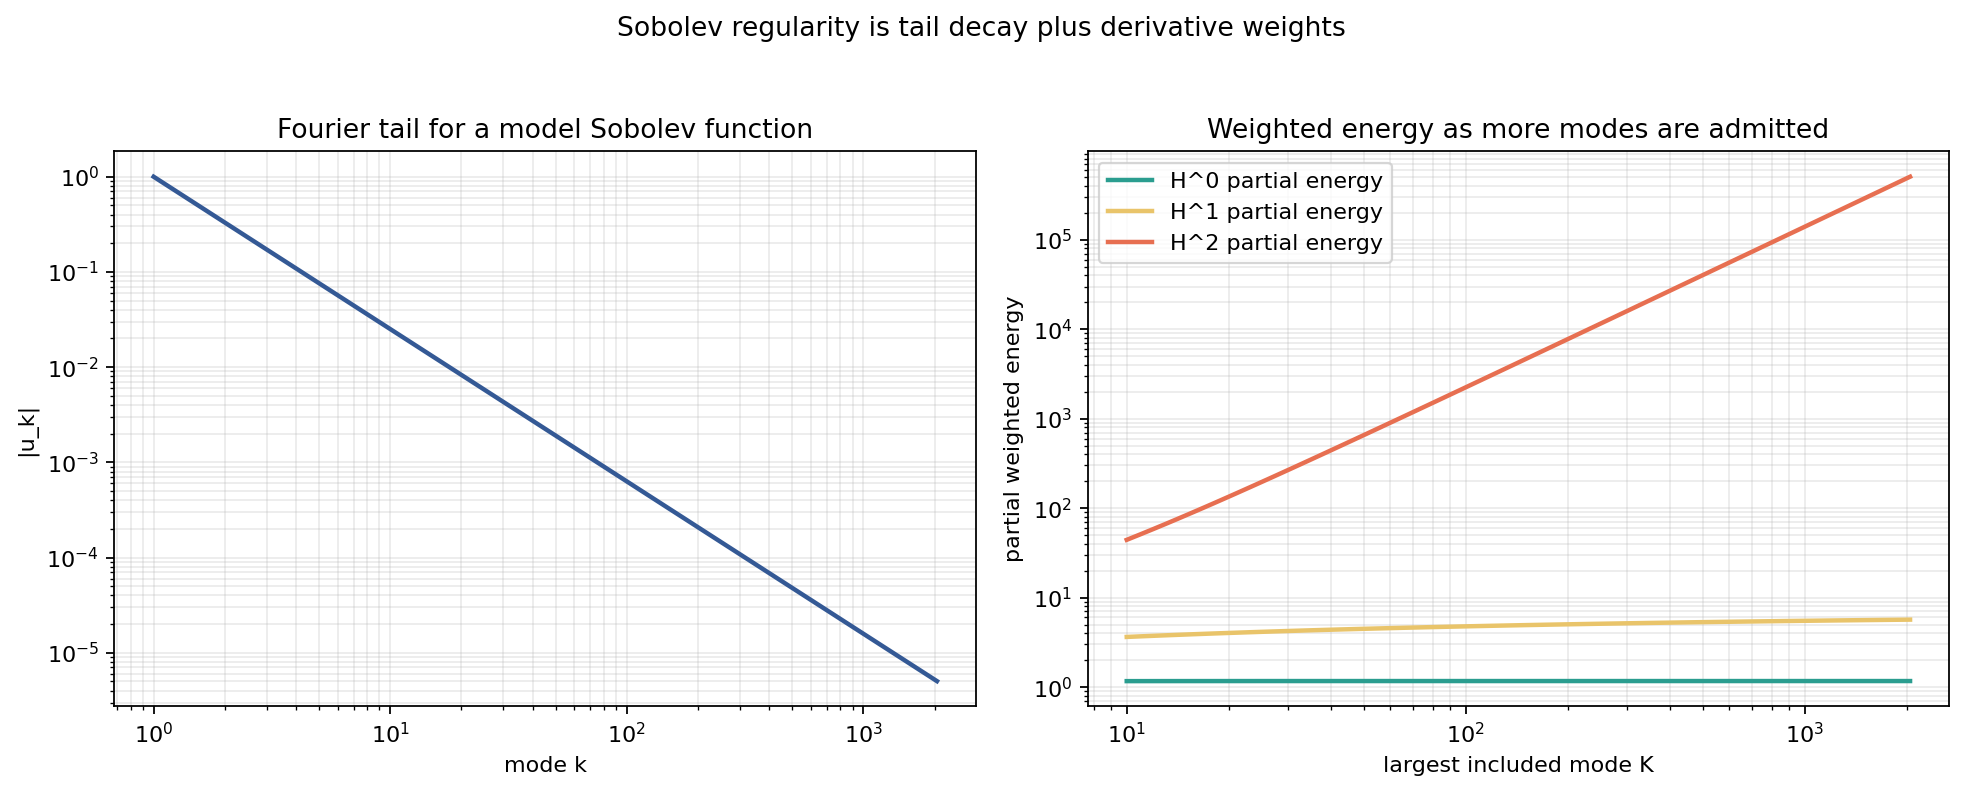

{'model': 'periodic p=2 Sobolev coefficients |u_k| = k^{-alpha}',
 'alpha': 1.6,
 'predicted_membership': 'H^s finite for s < alpha - 1/2 in the infinite-tail model',
 'threshold_s': 1.1,
 'H0_last_to_half_ratio': 1.0000000657900865,
 'H1_last_to_half_ratio': 1.027757357680077,
 'H2_last_to_half_ratio': 3.270746368576445,
 'passed': True}

In [3]:
K_MAX = 2048
k = np.arange(1, K_MAX + 1, dtype=float)
alpha = 1.60
coeff_abs = k ** (-alpha)
s_values = [0.0, 1.0, 2.0]
K_samples = np.unique(np.logspace(1, math.log10(K_MAX), 90).astype(int))

partial_energy = {}
for s in s_values:
    partial_energy[s] = np.array([
        np.sum(((1 + k[:K] ** 2) ** s) * coeff_abs[:K] ** 2)
        for K in K_samples
    ])

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))
axes[0].loglog(k, coeff_abs, color="#345995", linewidth=2.0)
axes[0].set_title("Fourier tail for a model Sobolev function")
axes[0].set_xlabel("mode k")
axes[0].set_ylabel("|u_k|")
axes[0].grid(True, which="both", alpha=0.25)

colors = {0.0: "#2a9d8f", 1.0: "#e9c46a", 2.0: "#e76f51"}
for s in s_values:
    axes[1].loglog(K_samples, partial_energy[s], label=f"H^{s:g} partial energy", color=colors[s], linewidth=2.0)
axes[1].set_title("Weighted energy as more modes are admitted")
axes[1].set_xlabel("largest included mode K")
axes[1].set_ylabel("partial weighted energy")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend()
fig.suptitle("Sobolev regularity is tail decay plus derivative weights", y=1.03)
fig.tight_layout()
sobolev_fig = save_matplotlib(fig, UNIT, "figures", "sobolev-frequency-weights.png")
plt.close(fig)

threshold = alpha - 0.5
ratio_last_half = {
    f"H{s:g}_last_to_half_ratio": float(partial_energy[s][-1] / partial_energy[s][np.searchsorted(K_samples, K_MAX // 2)])
    for s in s_values
}
sobolev_check = {
    "model": "periodic p=2 Sobolev coefficients |u_k| = k^{-alpha}",
    "alpha": alpha,
    "predicted_membership": "H^s finite for s < alpha - 1/2 in the infinite-tail model",
    "threshold_s": threshold,
    **ratio_last_half,
    "passed": bool(
        ratio_last_half["H0_last_to_half_ratio"] < 1.02
        and ratio_last_half["H1_last_to_half_ratio"] < 1.25
        and ratio_last_half["H2_last_to_half_ratio"] > 2.0
    ),
}
sobolev_json = save_json(sobolev_check, UNIT, "checks", "sobolev-frequency-checks.json")
display_artifact(sobolev_fig, width=840)
sobolev_check


## B.2 Calderon-Zygmund: Controlling The Hessian By The Laplacian

The Calderon-Zygmund inequality is the analytic bridge between knowing the Laplacian and controlling all second derivatives. In flat Fourier language, solving `-Delta u = f` gives `u_hat = f_hat / |xi|^2` away from the zero mode. A second derivative then has multiplier `xi_i xi_j / |xi|^2`. For `p=2`, the full Hessian identity is exact. For general `1 < p < infinity`, the appendix proves the corresponding `L^p` boundedness by singular-integral methods rather than by this elementary Hilbert-space calculation.

The heatmaps below are not the proof of Calderon-Zygmund. They are the symbol-level reason the estimate is plausible: second derivatives of an inverse Laplacian are order-zero operators, not order-two operators.


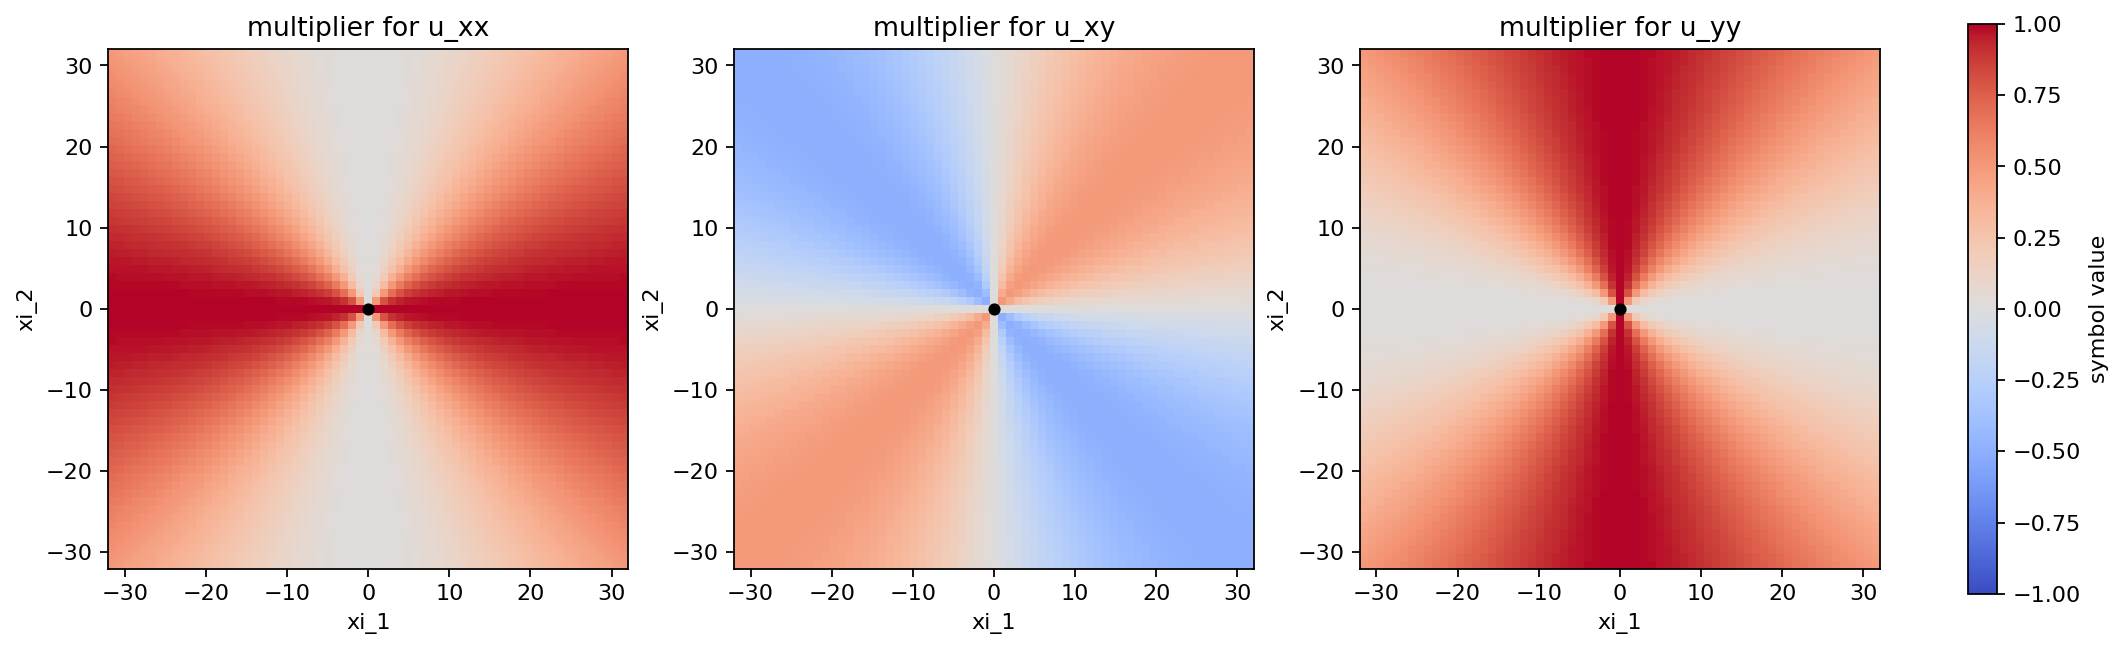

{'max_abs_multiplier': 1.0,
 'laplace_l2': 68.48183866118556,
 'hessian_l2': 68.48183866118556,
 'relative_l2_identity_error': 0.0,
 'sympy_hessian_identity_zero': True,
 'passed': True}

In [4]:
axis = np.arange(-32, 33)
X, Y = np.meshgrid(axis, axis)
R2 = X**2 + Y**2
mask = R2 == 0
R2_safe = np.where(mask, 1, R2)
M_xx = np.ma.array(X**2 / R2_safe, mask=mask)
M_xy = np.ma.array((X * Y) / R2_safe, mask=mask)
M_yy = np.ma.array(Y**2 / R2_safe, mask=mask)

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.3), constrained_layout=True)
for ax, data, title in zip(
    axes,
    [M_xx, M_xy, M_yy],
    ["multiplier for u_xx", "multiplier for u_xy", "multiplier for u_yy"],
):
    im = ax.imshow(data, origin="lower", extent=[axis.min(), axis.max(), axis.min(), axis.max()], cmap="coolwarm", norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1))
    ax.set_title(title)
    ax.set_xlabel("xi_1")
    ax.set_ylabel("xi_2")
    ax.scatter([0], [0], s=20, color="black")
fig.colorbar(im, ax=axes, shrink=0.85, label="symbol value")
cz_fig = save_matplotlib(fig, UNIT, "figures", "calderon-zygmund-symbols.png")
plt.close(fig)

rng = np.random.default_rng(4277)
N = 48
freq = np.fft.fftfreq(N) * N
KX, KY = np.meshgrid(freq, freq, indexing="ij")
KR2 = KX**2 + KY**2
nonzero = KR2 > 0
fhat = rng.normal(size=(N, N)) + 1j * rng.normal(size=(N, N))
fhat[~nonzero] = 0.0
uhat = np.zeros_like(fhat, dtype=complex)
uhat[nonzero] = fhat[nonzero] / KR2[nonzero]
uxx_hat = -(KX**2) * uhat
uxy_hat = -(KX * KY) * uhat
uyy_hat = -(KY**2) * uhat
laplace_l2 = float(np.sqrt(np.sum(np.abs(fhat) ** 2)))
hessian_l2 = float(np.sqrt(np.sum(np.abs(uxx_hat) ** 2 + 2 * np.abs(uxy_hat) ** 2 + np.abs(uyy_hat) ** 2)))

xi, eta = sp.symbols("xi eta", nonzero=True)
identity = sp.simplify((xi**4 + 2 * xi**2 * eta**2 + eta**4) / (xi**2 + eta**2) ** 2 - 1)
cz_check = {
    "max_abs_multiplier": float(max(np.max(np.abs(M_xx)), np.max(np.abs(M_xy)), np.max(np.abs(M_yy)))),
    "laplace_l2": laplace_l2,
    "hessian_l2": hessian_l2,
    "relative_l2_identity_error": float(abs(hessian_l2 - laplace_l2) / laplace_l2),
    "sympy_hessian_identity_zero": bool(identity == 0),
    "passed": bool(abs(hessian_l2 - laplace_l2) / laplace_l2 < 1e-12 and identity == 0),
}
cz_json = save_json(cz_check, UNIT, "checks", "calderon-zygmund-symbol-check.json")
display_artifact(cz_fig, width=860)
cz_check


## B.3 Laplace Regularity: A Weak Equation Gains Derivatives

Interior regularity for the Laplace operator combines three moves. First localize with a cutoff, so the problem is supported where the source data are controlled. Then compare with the convolution solution built from the fundamental solution. Finally, the difference is harmonic, so Weyl's lemma and harmonic estimates make the remainder smooth. The result is local: away from the boundary, a weak solution of a Laplace equation inherits two more derivatives than the right-hand side.

The existing Fourier smoothing idea is useful, so this notebook keeps it as `elliptic-fourier-smoothing.png` and makes its invariant explicit. In the periodic toy model, the inverse Laplacian divides every nonzero mode by `k^2`; multiplying the solution coefficients back by `k^2` recovers the forcing.


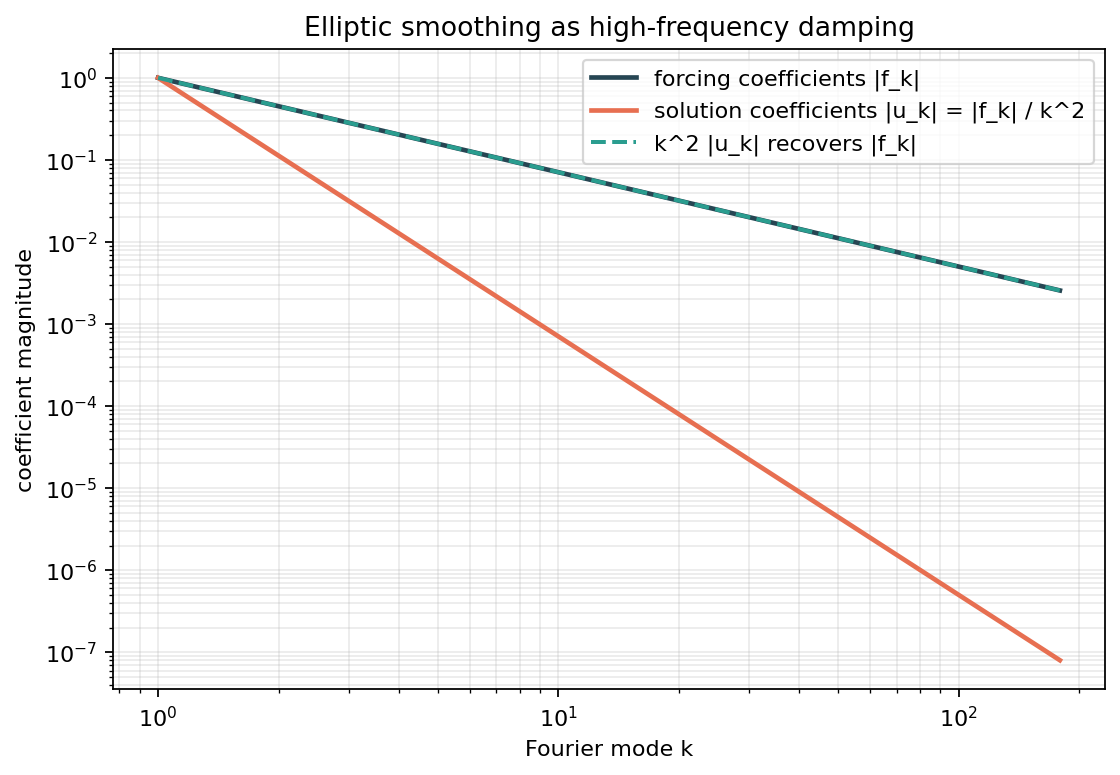

{'forcing_H0': 1.1964592035792412,
 'forcing_H1': 7.387213225427221,
 'solution_H2': 2.138685724892474,
 'solution_H3': 7.851158605384212,
 'inverse_laplace_residual': 1.3877787807814457e-17,
 'tail_gain_ratio_at_largest_mode': 32040.999999999996,
 'two_derivative_bound_ratio': 1.7875124521542698,
 'passed': True}

In [5]:
k = np.arange(1, 180, dtype=float)
forcing = 1 / (k ** 1.15)
solution = forcing / (k**2)
recovered_forcing = (k**2) * solution


def sobolev_norm(coeffs, s):
    return float(np.sqrt(np.sum((1 + k**2) ** s * coeffs**2)))


regularity_norms = {
    "forcing_H0": sobolev_norm(forcing, 0),
    "forcing_H1": sobolev_norm(forcing, 1),
    "solution_H2": sobolev_norm(solution, 2),
    "solution_H3": sobolev_norm(solution, 3),
}

fig, ax = plt.subplots(figsize=(8.0, 5.2))
ax.loglog(k, forcing, label="forcing coefficients |f_k|", linewidth=2.1, color="#264653")
ax.loglog(k, solution, label="solution coefficients |u_k| = |f_k| / k^2", linewidth=2.1, color="#e76f51")
ax.loglog(k, recovered_forcing, linestyle="--", label="k^2 |u_k| recovers |f_k|", linewidth=1.8, color="#2a9d8f")
ax.set_xlabel("Fourier mode k")
ax.set_ylabel("coefficient magnitude")
ax.set_title("Elliptic smoothing as high-frequency damping")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
fourier_fig = save_matplotlib(fig, UNIT, "figures", "elliptic-fourier-smoothing.png")
plt.close(fig)

laplace_check = {
    **regularity_norms,
    "inverse_laplace_residual": float(np.max(np.abs(recovered_forcing - forcing))),
    "tail_gain_ratio_at_largest_mode": float(forcing[-1] / solution[-1]),
    "two_derivative_bound_ratio": float(regularity_norms["solution_H2"] / regularity_norms["forcing_H0"]),
    "passed": bool(
        np.max(np.abs(recovered_forcing - forcing)) < 1e-14
        and regularity_norms["solution_H2"] < 2.05 * regularity_norms["forcing_H0"]
        and forcing[-1] / solution[-1] > 10000
    ),
}
laplace_json = save_json(laplace_check, UNIT, "checks", "elliptic-regularity-checks.json")
display_artifact(fourier_fig, width=720)
laplace_check


## Weak-To-Smooth Upgrade As A Proof Dependency Graph

The weak-to-smooth upgrade is not a single theorem used once. It is a chain of local reductions. A weak Cauchy-Riemann type equation is rewritten in coordinates, differentiated or tested to produce a Laplace/divergence-form equation, estimated locally, improved by Sobolev embedding and product estimates, and then iterated. The graph below records those dependencies as a directed acyclic graph.

Read an arrow as "this estimate or reduction is needed before the next regularity statement is available." The terminal node is deliberately geometric: the analytic upgrade returns a smooth curve, not just a better distribution.


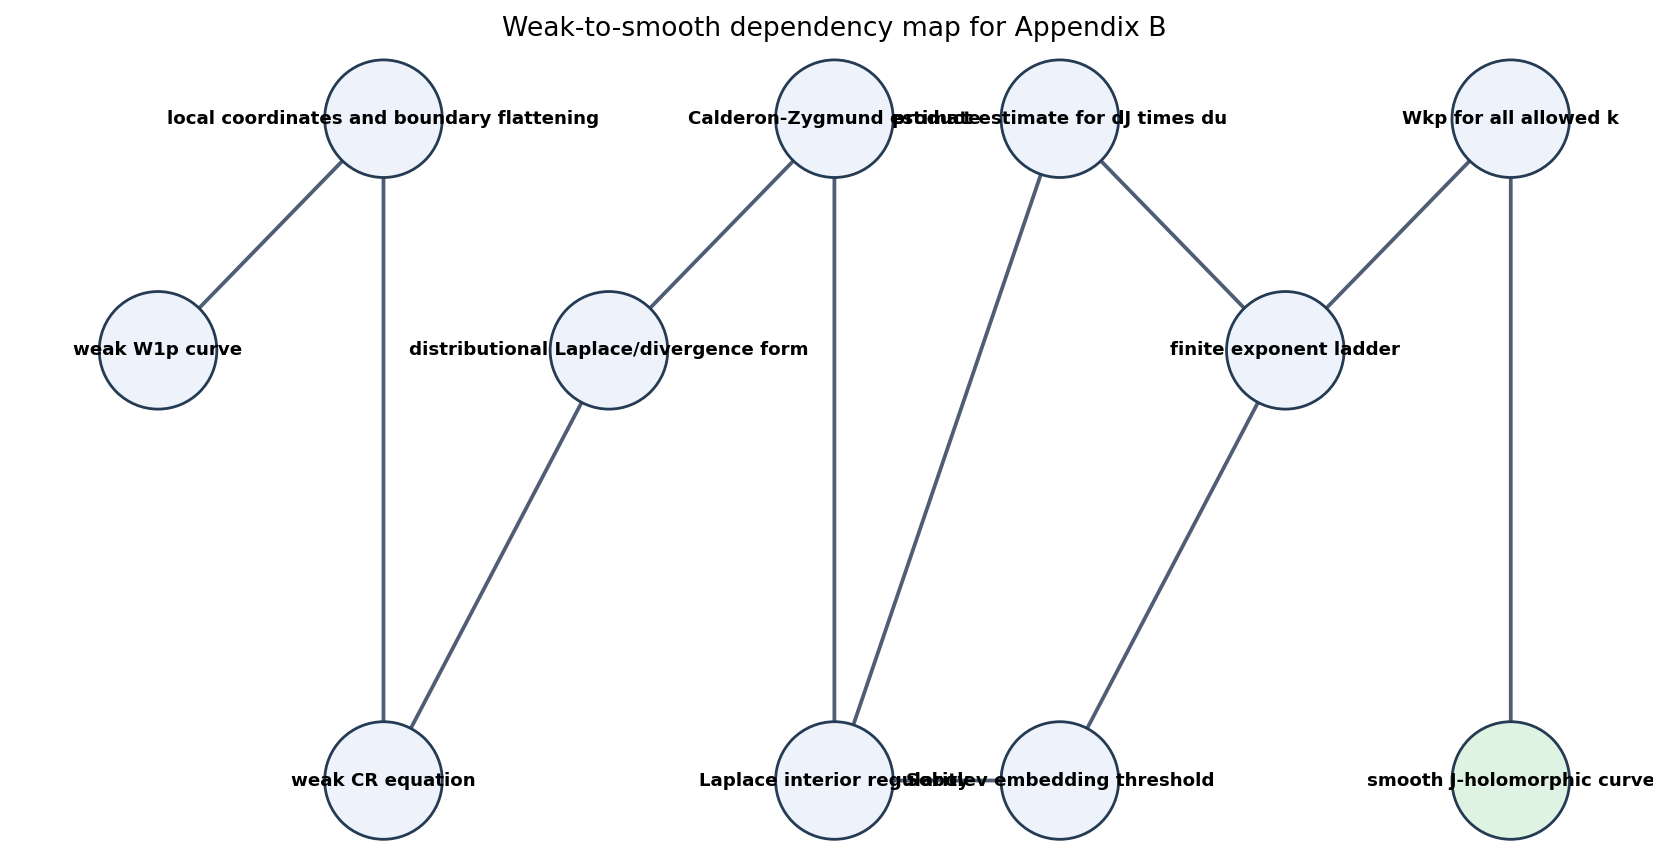

{'nodes': 11,
 'edges': 11,
 'is_directed_acyclic_graph': True,
 'has_weak_start': True,
 'has_smooth_terminal': True,
 'path_length_weak_to_smooth': 9,
 'passed': True}

In [6]:
proof_nodes = {
    "weak W1p curve": "start",
    "local coordinates and boundary flattening": "localize",
    "weak CR equation": "equation",
    "distributional Laplace/divergence form": "laplace",
    "Calderon-Zygmund estimate": "estimate",
    "Laplace interior regularity": "regularity",
    "product estimate for dJ times du": "product",
    "Sobolev embedding threshold": "embedding",
    "finite exponent ladder": "bootstrap",
    "Wkp for all allowed k": "smoothness",
    "smooth J-holomorphic curve": "geometry",
}
proof_edges = [
    ("weak W1p curve", "local coordinates and boundary flattening"),
    ("local coordinates and boundary flattening", "weak CR equation"),
    ("weak CR equation", "distributional Laplace/divergence form"),
    ("distributional Laplace/divergence form", "Calderon-Zygmund estimate"),
    ("Calderon-Zygmund estimate", "Laplace interior regularity"),
    ("Laplace interior regularity", "product estimate for dJ times du"),
    ("product estimate for dJ times du", "finite exponent ladder"),
    ("Sobolev embedding threshold", "finite exponent ladder"),
    ("finite exponent ladder", "Wkp for all allowed k"),
    ("Wkp for all allowed k", "smooth J-holomorphic curve"),
    ("Laplace interior regularity", "Sobolev embedding threshold"),
]
G = nx.DiGraph()
G.add_nodes_from(proof_nodes)
G.add_edges_from(proof_edges)
layer_order = [
    ["weak W1p curve"],
    ["local coordinates and boundary flattening", "weak CR equation"],
    ["distributional Laplace/divergence form"],
    ["Calderon-Zygmund estimate", "Laplace interior regularity"],
    ["product estimate for dJ times du", "Sobolev embedding threshold"],
    ["finite exponent ladder"],
    ["Wkp for all allowed k", "smooth J-holomorphic curve"],
]
pos = {}
for x, layer in enumerate(layer_order):
    for y, node in enumerate(layer):
        pos[node] = (x, -y + 0.35 * (len(layer) - 1))

fig, ax = plt.subplots(figsize=(13.2, 6.5))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.7, edge_color="#4f5d75")
node_colors = ["#dff3e3" if node == "smooth J-holomorphic curve" else "#edf2fb" for node in G.nodes]
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2800, node_color=node_colors, edgecolors="#243b53", linewidths=1.25)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8.2, font_weight="bold")
ax.set_title("Weak-to-smooth dependency map for Appendix B")
ax.set_axis_off()
proof_fig = save_matplotlib(fig, UNIT, "figures", "proof-dependency-map.png")
plt.close(fig)

proof_check = {
    "nodes": G.number_of_nodes(),
    "edges": G.number_of_edges(),
    "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(G),
    "has_weak_start": "weak W1p curve" in G.nodes,
    "has_smooth_terminal": "smooth J-holomorphic curve" in G.nodes,
    "path_length_weak_to_smooth": nx.shortest_path_length(G, "weak W1p curve", "smooth J-holomorphic curve"),
    "passed": bool(nx.is_directed_acyclic_graph(G) and nx.has_path(G, "weak W1p curve", "smooth J-holomorphic curve")),
}
proof_json = save_json(proof_check, UNIT, "checks", "proof-dependency-map.json")
display_artifact(proof_fig, width=900)
proof_check


## B.4 Elliptic Bootstrapping: The Exponent Ladder

The delicate point in B.4 is the product `(dJ)(du)`. If both factors are only in `L^p`, their product can fall to `L^{p/2}`, which is not good enough when `p` is just above 2. The appendix handles this by improving the exponent of `du` while keeping the regularity of `J` fixed.

The model below uses the two-dimensional Sobolev embedding step. If `dJ` is in `L^p` and `du` is in `L^q`, Holder gives a source term in `L^r` with `1/r = 1/p + 1/q`. If `r < 2`, then `W^{1,r}` embeds into `L^{2r/(2-r)}`, improving `q`. Once `r > 2`, embedding gives continuity, and the product returns to `L^p`. That is the finite ladder behind the weak-to-smooth upgrade.


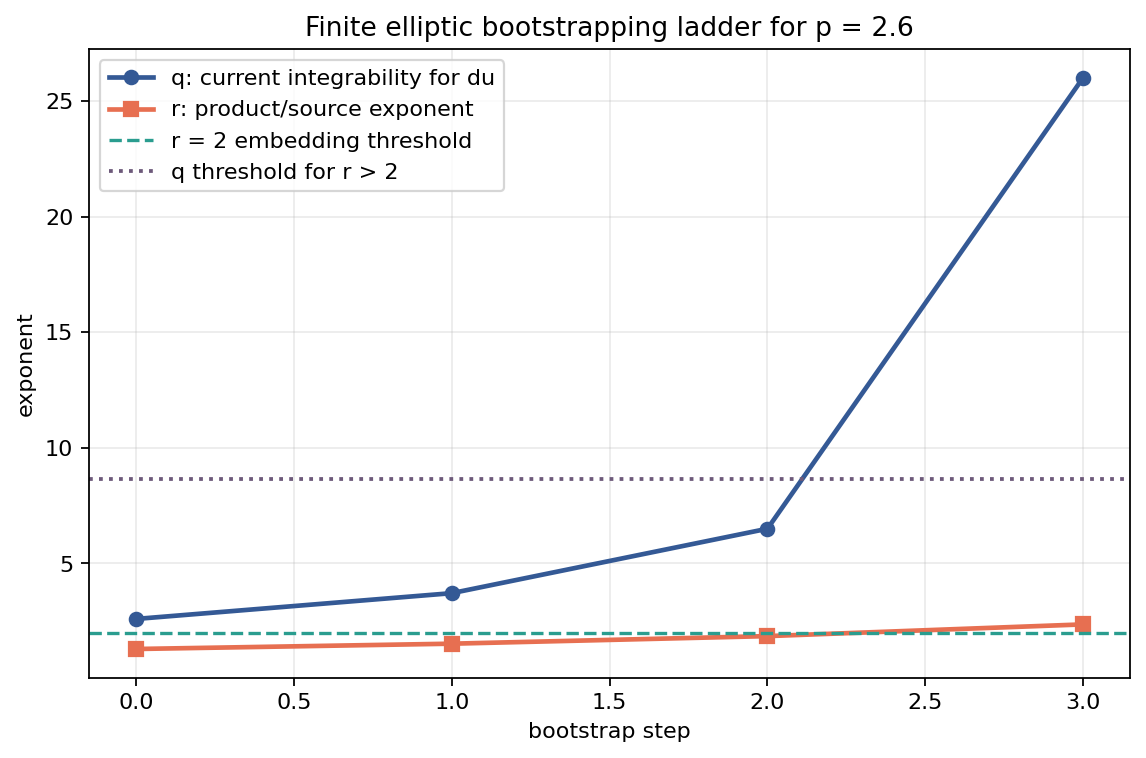

,step,p,q,r,q_next,critical_q_for_r_gt_2,status
0,0,2.6,2.600000,1.300000,3.714286,8.666667,improve q by W1r -> Lq_next
1,1,2.6,3.714286,1.529412,6.500000,8.666667,improve q by W1r -> Lq_next
2,2,2.6,6.500000,1.857143,26.000000,8.666667,improve q by W1r -> Lq_next
3,3,2.6,26.000000,2.363636,inf,8.666667,"r > 2: Sobolev embedding gives continuity, the..."


In [7]:
def bootstrap_ladder(p, q0=None, max_steps=16):
    if p <= 2:
        raise ValueError("This model needs p > 2, matching the appendix's boundary bootstrapping hypothesis.")
    q = float(q0 if q0 is not None else p)
    rows = []
    for step in range(max_steps):
        r = p * q / (p + q)
        critical_q = 2 * p / (p - 2)
        if r > 2:
            q_next = math.inf
            status = "r > 2: Sobolev embedding gives continuity, then recover Lp source"
        elif math.isclose(r, 2.0, rel_tol=1e-12, abs_tol=1e-12):
            q_next = 1.1 * critical_q
            status = "borderline r = 2: choose a finite q beyond the threshold"
        else:
            q_next = 2 * r / (2 - r)
            status = "improve q by W1r -> Lq_next"
        rows.append({
            "step": step,
            "p": p,
            "q": q,
            "r": r,
            "q_next": q_next,
            "critical_q_for_r_gt_2": critical_q,
            "status": status,
        })
        if r > 2:
            break
        if q_next <= q:
            raise RuntimeError("Bootstrap did not improve q; check the initial exponent.")
        q = q_next
    return rows


p_model = 2.6
ladder_rows = bootstrap_ladder(p_model)
ladder_df = pd.DataFrame(ladder_rows)

fig, ax = plt.subplots(figsize=(8.4, 5.1))
ax.plot(ladder_df["step"], ladder_df["q"], marker="o", linewidth=2.1, label="q: current integrability for du", color="#345995")
ax.plot(ladder_df["step"], ladder_df["r"], marker="s", linewidth=2.1, label="r: product/source exponent", color="#e76f51")
ax.axhline(2, color="#2a9d8f", linestyle="--", linewidth=1.5, label="r = 2 embedding threshold")
ax.axhline(2 * p_model / (p_model - 2), color="#6d597a", linestyle=":", linewidth=1.7, label="q threshold for r > 2")
ax.set_xlabel("bootstrap step")
ax.set_ylabel("exponent")
ax.set_title(f"Finite elliptic bootstrapping ladder for p = {p_model}")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left")
boot_png = save_matplotlib(fig, UNIT, "figures", "bootstrapping-exponent-ladder.png")
plt.close(fig)

plotly_fig = go.Figure()
plotly_fig.add_trace(go.Scatter(x=ladder_df["step"], y=ladder_df["q"], mode="lines+markers", name="q for du"))
plotly_fig.add_trace(go.Scatter(x=ladder_df["step"], y=ladder_df["r"], mode="lines+markers", name="r for source"))
plotly_fig.add_hline(y=2, line_dash="dash", annotation_text="r = 2")
plotly_fig.add_hline(y=2 * p_model / (p_model - 2), line_dash="dot", annotation_text="q threshold")
plotly_fig.update_layout(
    title=f"Elliptic bootstrapping exponent ladder, p = {p_model}",
    xaxis_title="bootstrap step",
    yaxis_title="exponent",
    template="plotly_white",
    width=820,
    height=500,
)
boot_html = HTML_DIR / "bootstrapping-exponent-ladder.html"
plotly_fig.write_html(boot_html, include_plotlyjs=True, full_html=True)

boot_check = {
    "p": p_model,
    "steps": len(ladder_rows),
    "q_values": [float(row["q"]) for row in ladder_rows],
    "r_values": [float(row["r"]) for row in ladder_rows],
    "q_strictly_increases_until_terminal": bool(all(ladder_rows[i + 1]["q"] > ladder_rows[i]["q"] for i in range(len(ladder_rows) - 2))),
    "terminal_r": float(ladder_rows[-1]["r"]),
    "terminal_r_exceeds_two": bool(ladder_rows[-1]["r"] > 2),
    "passed": bool(ladder_rows[-1]["r"] > 2 and len(ladder_rows) <= 16),
}
boot_json = save_json(boot_check, UNIT, "checks", "bootstrapping-exponent-ladder.json")
display_artifact(boot_png, width=760)
display_artifact(boot_html, width="100%", height=520)
ladder_df


## Applied Lab: Change The Initial Integrability

The lab is intentionally small: change `p` and rerun the ladder. Values of `p` close to 2 need more steps because the threshold `q > 2p/(p-2)` moves far away. Larger `p` reaches continuity quickly. This mirrors the role of the hypothesis `p > 2` in the curve regularity and compactness statements: it puts two-dimensional Sobolev embedding on the right side of the argument.


In [8]:
lab_rows = []
for p in [2.2, 2.4, 2.6, 3.0, 4.0, 6.0]:
    rows = bootstrap_ladder(p)
    lab_rows.append({
        "p": p,
        "ladder_steps": len(rows),
        "critical_q_for_r_gt_2": 2 * p / (p - 2),
        "terminal_r": rows[-1]["r"],
        "terminal_q": rows[-1]["q"],
    })
lab_df = pd.DataFrame(lab_rows)
lab_csv = write_csv(lab_rows, TABLE_DIR / "bootstrapping-lab-grid.csv", ["p", "ladder_steps", "critical_q_for_r_gt_2", "terminal_r", "terminal_q"])
lab_json = save_json({
    "rows": lab_rows,
    "all_terminal_r_exceeds_two": bool(all(row["terminal_r"] > 2 for row in lab_rows)),
    "harder_near_two": bool(lab_rows[0]["ladder_steps"] > lab_rows[-1]["ladder_steps"]),
    "passed": bool(all(row["terminal_r"] > 2 for row in lab_rows) and lab_rows[0]["ladder_steps"] > lab_rows[-1]["ladder_steps"]),
}, UNIT, "checks", "bootstrapping-lab-grid.json")
display(lab_df)
display_artifact(lab_csv)


,p,ladder_steps,critical_q_for_r_gt_2,terminal_r,terminal_q
0,2.2,10,22.000000,2.000000,22.0
1,2.4,6,12.000000,2.030769,13.2
2,2.6,4,8.666667,2.363636,26.0
3,3.0,3,6.000000,2.062500,6.6
4,4.0,2,4.000000,2.095238,4.4
5,6.0,1,3.000000,3.000000,6.0


## Takeaways

- Sobolev spaces are the staging area: they encode weak derivatives well enough for Banach-space analysis.
- Calderon-Zygmund is the key estimate that prevents second derivatives of an inverse Laplacian from costing two uncontrolled derivatives.
- Laplace regularity upgrades weak solutions locally by comparing with a fundamental-solution model plus a harmonic remainder.
- Elliptic bootstrapping is a finite exponent improvement followed by induction in derivative order.
- In the curve setting, the payoff is geometric: a weak `W^{1,p}` solution of the pseudoholomorphic curve equation becomes smooth when the almost complex structure is smooth.

## Final Sanity Checks

The final cell checks artifact existence, nonzero size, source coverage, storyboard completeness, and the main symbolic/numeric invariants. It intentionally contains several literal `assert_artifact(...)` calls so a quick text audit can see that artifact checks are not hidden inside a loop only.


In [9]:
check_paths = [
    source_json,
    library_json,
    story_json,
    ledger_json,
    sobolev_json,
    cz_json,
    laplace_json,
    proof_json,
    boot_json,
    lab_json,
]
artifact_paths = [
    ledger_csv,
    lab_csv,
    sobolev_fig,
    cz_fig,
    fourier_fig,
    proof_fig,
    boot_png,
    boot_html,
    *check_paths,
]

assert_artifact(FIG_DIR / "sobolev-frequency-weights.png", min_bytes=2048)
assert_artifact(FIG_DIR / "calderon-zygmund-symbols.png", min_bytes=2048)
assert_artifact(FIG_DIR / "elliptic-fourier-smoothing.png", min_bytes=2048)
assert_artifact(FIG_DIR / "proof-dependency-map.png", min_bytes=2048)
assert_artifact(FIG_DIR / "bootstrapping-exponent-ladder.png", min_bytes=2048)
assert_artifact(HTML_DIR / "bootstrapping-exponent-ladder.html", min_bytes=2048)
assert_artifact(CHECK_DIR / "visual-storyboard.json", min_bytes=512)
assert_artifact(CHECK_DIR / "source-coverage.json", min_bytes=512)

for path in artifact_paths:
    min_bytes = 80 if path.suffix in {".csv", ".json"} else 512
    assert_artifact(path, min_bytes=min_bytes)

check_payloads = {rel(path): json.loads(Path(path).read_text(encoding="utf-8")) for path in check_paths}
failed_checks = [name for name, payload in check_payloads.items() if payload.get("passed") is not True]
assert not failed_checks, failed_checks
assert len(source_coverage) == 4
assert {row["source_section"].split()[0] for row in source_coverage} == {"B.1", "B.2", "B.3", "B.4"}
assert cz_check["sympy_hessian_identity_zero"] is True
assert laplace_check["inverse_laplace_residual"] < 1e-14
assert boot_check["terminal_r_exceeds_two"] is True
assert proof_check["is_directed_acyclic_graph"] is True

final_sanity = {
    "source_span": SOURCE_SPAN,
    "artifact_count": len(artifact_paths),
    "check_count": len(check_paths),
    "artifact_sizes": {rel(path): Path(path).stat().st_size for path in artifact_paths},
    "literal_assert_artifact_calls_in_cell": 9,
    "source_sections_covered": [row["source_section"] for row in source_coverage],
    "core_validations": {
        "sobolev_tail_threshold": sobolev_check["passed"],
        "calderon_zygmund_l2_identity": cz_check["passed"],
        "laplace_two_derivative_gain": laplace_check["passed"],
        "weak_to_smooth_dag": proof_check["passed"],
        "bootstrapping_ladder_terminates": boot_check["passed"],
    },
    "passed": True,
}
final_json = save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(CHECK_DIR / "final-sanity.json", min_bytes=512)
print(f"Validated {len(artifact_paths)} appendix-b artifacts and {len(check_paths) + 1} JSON check files.")


Validated 18 appendix-b artifacts and 11 JSON check files.
